In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

from scipy import stats
from scipy.stats.mstats import winsorize

import warnings
warnings.filterwarnings('ignore')

In [8]:
np.random.seed(42)

feat_1 = np.random.normal(loc=60, scale=6, size=200)
feat_2 = np.random.exponential(scale=60, size=200)
f = np.random.normal(loc=15, scale=3, size=195)
feat_3 = np.append(f, [f.max()+50, f.max()+100, f.max()+150, f.max()+200, f.max()+250])

df = pd.DataFrame({
    "Normal": feat_1,
    "Skewed": feat_2,
    "with_outlier": feat_3
})

df.head()

,Normal,Skewed,with_outlier
0,62.980285,125.916518,14.673720
1,59.170414,81.002055,16.205135
2,63.886131,71.644466,17.070432
3,69.138179,72.737253,13.796339
4,58.595080,26.729541,15.672277


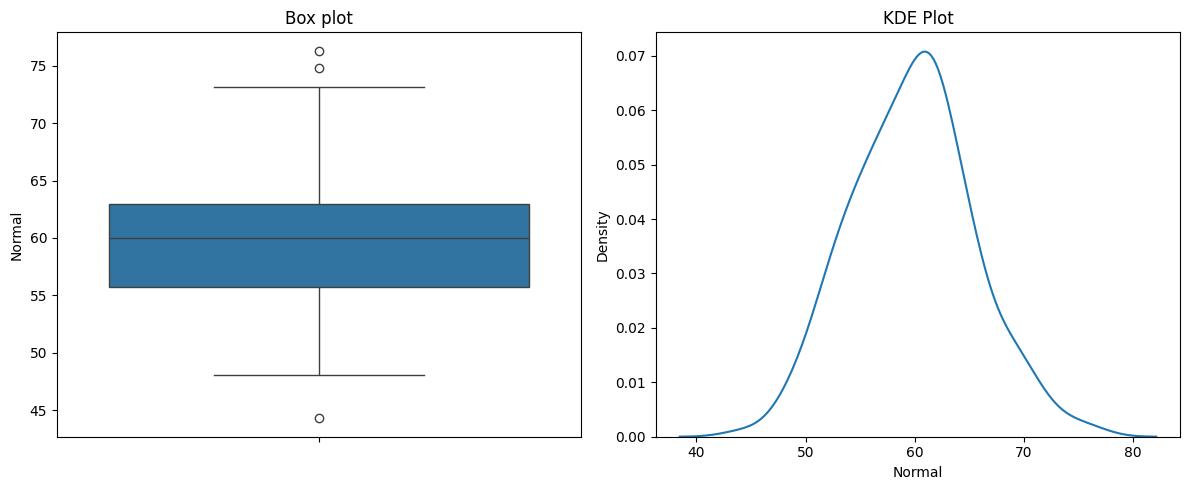

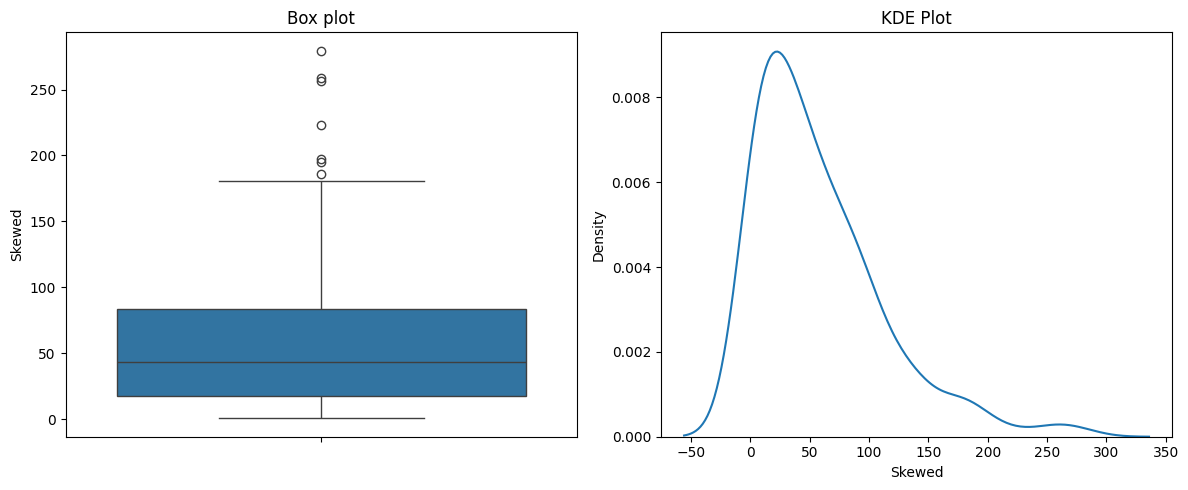

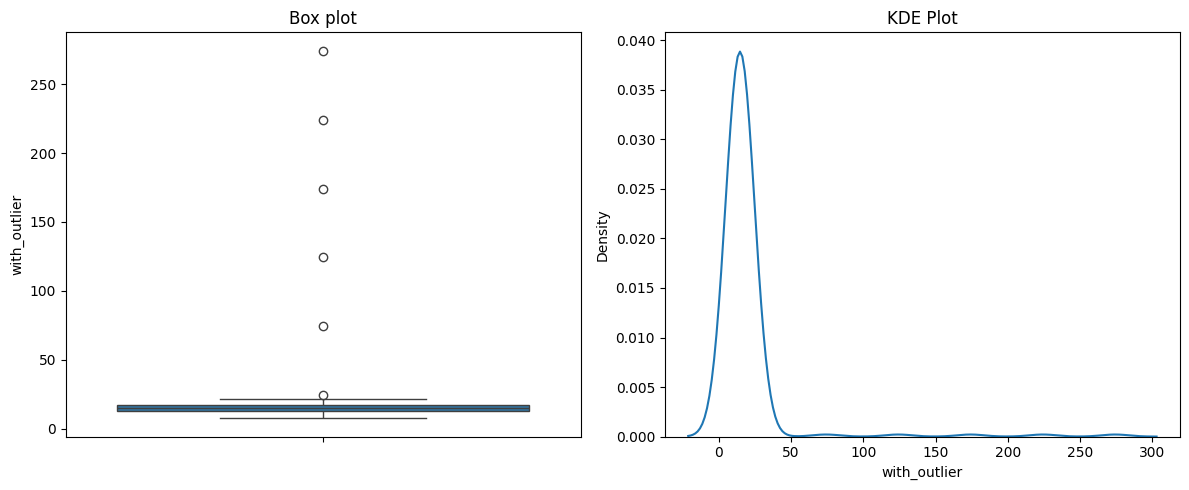

In [12]:
for col in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    sns.boxplot(df[col], ax=axes[0]).set_title("Box plot")
    sns.kdeplot(df[col], ax=axes[1]).set_title("KDE Plot")

    plt.tight_layout()
    plt.show()

In [15]:
minmax = MinMaxScaler()
stand = StandardScaler()
robust = RobustScaler()

minmaxscaler = minmax.fit_transform(df)
standardscaler = stand.fit_transform(df)
robustscaler = robust.fit_transform(df)

In [16]:
df_minmax = pd.DataFrame(minmaxscaler, columns=df.columns)
df_stand = pd.DataFrame(standardscaler, columns=df.columns)
df_robust = pd.DataFrame(robustscaler, columns=df.columns)

<Axes: >

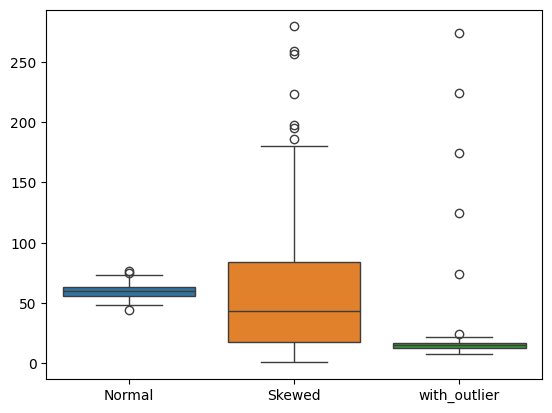

In [19]:
sns.boxplot(df)

<Axes: >

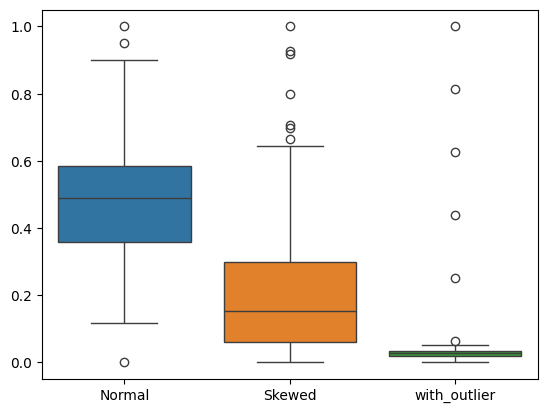

In [20]:
sns.boxplot(df_minmax)

<Axes: >

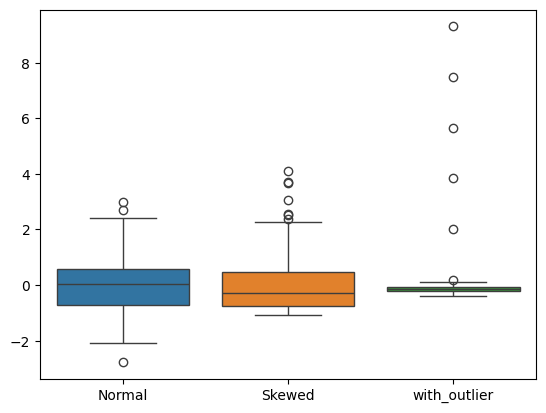

In [21]:
sns.boxplot(df_stand)

<Axes: >

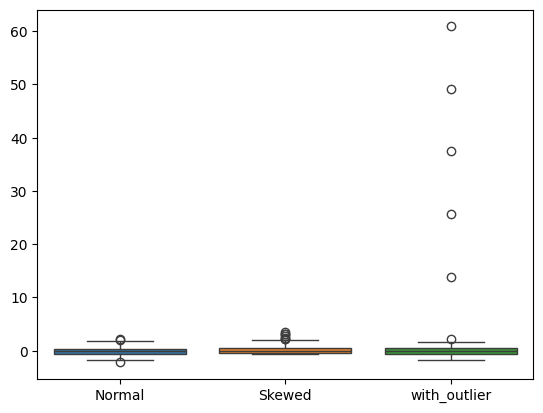

In [22]:
sns.boxplot(df_robust)

<Axes: >

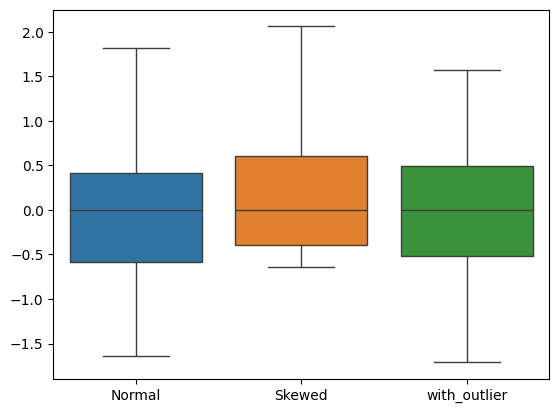

In [25]:
sns.boxplot(df_robust, showfliers=False)

In [26]:
df_bounding = df.copy()
df_bounding["without_outlier"] = np.clip(df["with_outlier"], 0, 200)

Text(0.5, 1.0, 'Without outliers')

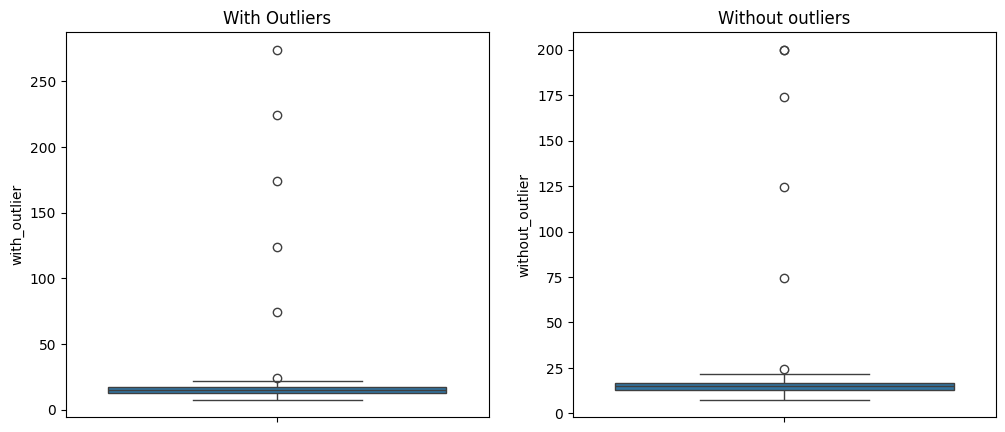

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(df["with_outlier"], ax=axes[0]).set_title("With Outliers")
sns.boxplot(df_bounding["without_outlier"], ax=axes[1]).set_title("Without outliers")

In [29]:
df_winsorize = df.copy()
df_winsorize["without_outlier"] = winsorize(df["with_outlier"], [0.05, 0.05])

Text(0.5, 1.0, 'Without outliers')

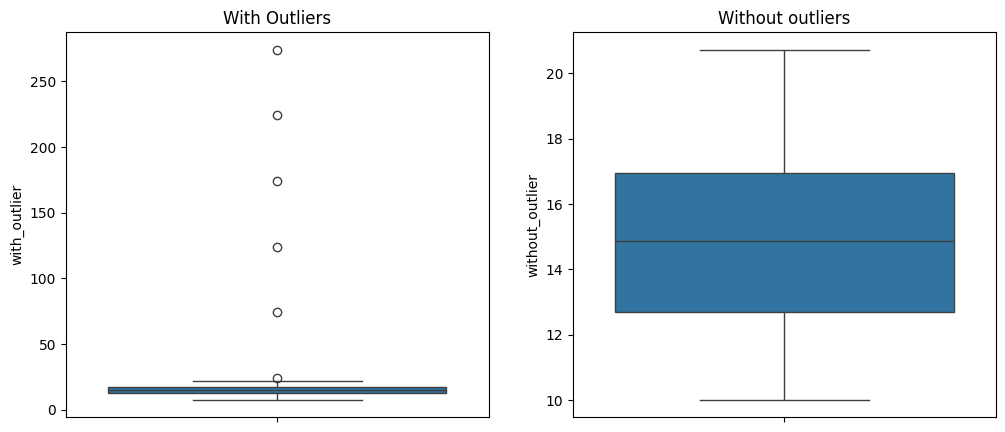

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(df["with_outlier"], ax=axes[0]).set_title("With Outliers")
sns.boxplot(df_winsorize["without_outlier"], ax=axes[1]).set_title("Without outliers")